In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [13]:
import pandas as pd

file_path = "/content/drive/MyDrive/OASIS/Customer_Segmentation.csv"
df = pd.read_csv(file_path)

df.head()

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,AcceptedCmpOverall,Total Puchases,Freq_Level,Spending_Level,Customer_Segment
0,7500,0,0,24,3,18,14,15,22,50,...,0,0,0,72,22,0,10,Medium,Low,Low Value
1,14421,0,0,81,0,0,2,3,3,8,...,0,0,0,8,0,1,4,Low,Low,Low Value
2,34824,0,0,65,4,2,11,2,0,4,...,1,0,0,19,15,0,4,Low,Low,Low Value
3,71163,0,0,30,283,17,372,138,106,44,...,1,0,0,916,872,0,24,High,Medium,Low Value
4,34824,0,0,65,4,2,11,2,0,4,...,1,0,0,19,15,0,4,Low,Low,Low Value


In [14]:
df.shape

(2205, 43)

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2205 entries, 0 to 2204
Data columns (total 43 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Income                2205 non-null   int64 
 1   Kidhome               2205 non-null   int64 
 2   Teenhome              2205 non-null   int64 
 3   Recency               2205 non-null   int64 
 4   MntWines              2205 non-null   int64 
 5   MntFruits             2205 non-null   int64 
 6   MntMeatProducts       2205 non-null   int64 
 7   MntFishProducts       2205 non-null   int64 
 8   MntSweetProducts      2205 non-null   int64 
 9   MntGoldProds          2205 non-null   int64 
 10  NumDealsPurchases     2205 non-null   int64 
 11  NumWebPurchases       2205 non-null   int64 
 12  NumCatalogPurchases   2205 non-null   int64 
 13  NumStorePurchases     2205 non-null   int64 
 14  NumWebVisitsMonth     2205 non-null   int64 
 15  AcceptedCmp3          2205 non-null   

In [16]:
df.describe()

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,marital_Widow,education_2n Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,AcceptedCmpOverall,Total Puchases
count,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,...,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.00000,2205.000000
mean,51622.094785,0.442177,0.506576,49.009070,306.164626,26.403175,165.312018,37.756463,27.128345,44.057143,...,0.034467,0.089796,0.024490,0.504762,0.165079,0.215873,562.764626,518.707483,0.29932,14.887982
std,20713.063826,0.537132,0.544380,28.932111,337.493839,39.784484,217.784507,54.824635,41.130468,51.736211,...,0.182467,0.285954,0.154599,0.500091,0.371336,0.411520,575.936911,553.847248,0.68044,7.615277
min,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,-283.000000,0.00000,0.000000
25%,35196.000000,0.000000,0.000000,24.000000,24.000000,2.000000,16.000000,3.000000,1.000000,9.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,56.000000,42.000000,0.00000,8.000000
50%,51287.000000,0.000000,0.000000,49.000000,178.000000,8.000000,68.000000,12.000000,8.000000,25.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,343.000000,288.000000,0.00000,15.000000
75%,68281.000000,1.000000,1.000000,74.000000,507.000000,33.000000,232.000000,50.000000,34.000000,56.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,964.000000,884.000000,0.00000,21.000000
max,113734.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,262.000000,321.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2491.000000,2458.000000,4.00000,43.000000


In [18]:
X = df[['Income', 'MntTotal']]

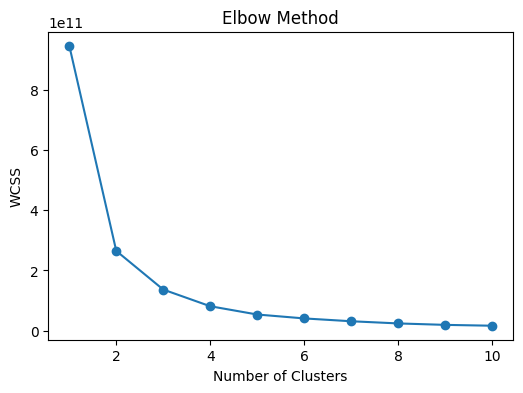

In [19]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [20]:
kmeans = KMeans(n_clusters=5, random_state=42)
y_kmeans = kmeans.fit_predict(X)

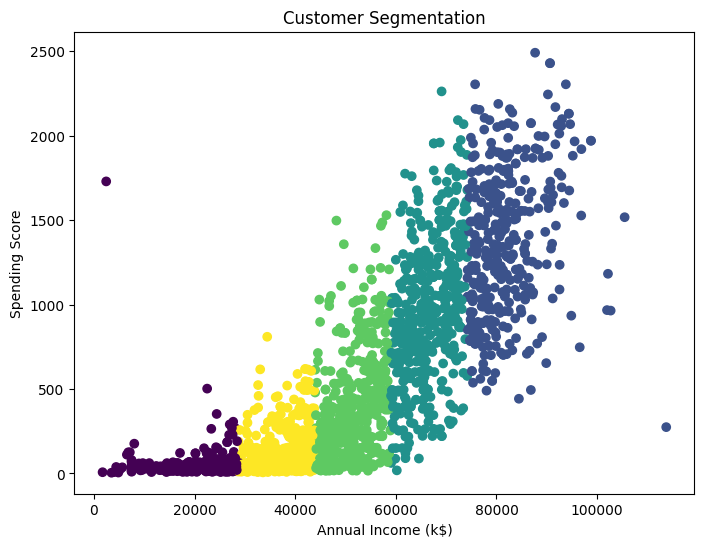

In [21]:
plt.figure(figsize=(8,6))

plt.scatter(X.iloc[:,0], X.iloc[:,1], c=y_kmeans, cmap='viridis')

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score")
plt.title("Customer Segmentation")

plt.show()

In [22]:
df['Cluster'] = y_kmeans
df.head()

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,education_Master,education_PhD,MntTotal,MntRegularProds,AcceptedCmpOverall,Total Puchases,Freq_Level,Spending_Level,Customer_Segment,Cluster
0,7500,0,0,24,3,18,14,15,22,50,...,0,0,72,22,0,10,Medium,Low,Low Value,0
1,14421,0,0,81,0,0,2,3,3,8,...,0,0,8,0,1,4,Low,Low,Low Value,0
2,34824,0,0,65,4,2,11,2,0,4,...,0,0,19,15,0,4,Low,Low,Low Value,4
3,71163,0,0,30,283,17,372,138,106,44,...,0,0,916,872,0,24,High,Medium,Low Value,2
4,34824,0,0,65,4,2,11,2,0,4,...,0,0,19,15,0,4,Low,Low,Low Value,4


In [24]:
df.groupby('Cluster').mean(numeric_only=True)

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,marital_Widow,education_2n Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,AcceptedCmpOverall,Total Puchases
Cluster,,,,,,,,,,,,,,,,,,,,,
0,20832.663743,0.760234,0.172515,49.994152,12.581871,6.008772,21.359649,8.263158,6.456140,17.643275,...,0.014620,0.152047,0.152047,0.514620,0.105263,0.076023,54.669591,37.026316,0.067251,7.365497
1,82060.076294,0.073569,0.228883,49.956403,668.588556,65.029973,469.752044,93.397820,68.978202,71.419619,...,0.035422,0.087193,0.000000,0.523161,0.168937,0.220708,1365.746594,1294.326975,0.937330,20.953678
2,66475.040486,0.129555,0.627530,48.655870,534.283401,45.502024,260.080972,62.678138,44.661943,68.672065,...,0.040486,0.072874,0.000000,0.524291,0.155870,0.246964,947.206478,878.534413,0.279352,20.712551
3,51410.428274,0.419958,0.856549,49.365904,269.399168,13.203742,80.920998,20.503119,14.534304,41.829522,...,0.051975,0.079002,0.000000,0.461538,0.189189,0.270270,398.561331,356.731809,0.203742,15.933472
4,36504.441459,0.809981,0.483685,47.700576,61.230326,6.658349,33.408829,10.220729,6.220729,20.838772,...,0.024952,0.076775,0.003839,0.506718,0.188100,0.224568,117.738964,96.900192,0.109405,9.065259
